In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
ruta = "../out/espectros_CR39.out"

espectros = {}
numero_actual = None
leyendo = False

with open(ruta, "r") as f:
    for linea in f:

        if "no. =" in linea and "reg =" in linea:
            try:
                numero_actual = int(linea.split("no. =")[1].split()[0])
            except:
                pass

        if "#  e-lower" in linea and "e-upper" in linea:
            leyendo = True
            energia = []
            flujo = []
            continue

        if leyendo and "#   sum over" in linea:
            espectros[numero_actual] = (
                np.array(energia),
                np.array(flujo)
            )
            leyendo = False
            continue

        if leyendo:
            datos = linea.split()

            if len(datos) >= 4:
                try:
                    e_lower = float(datos[0])
                    e_upper = float(datos[1])
                    valor = float(datos[2])

                    energia.append((e_lower + e_upper) / 2)
                    flujo.append(valor)

                except ValueError:
                    pass

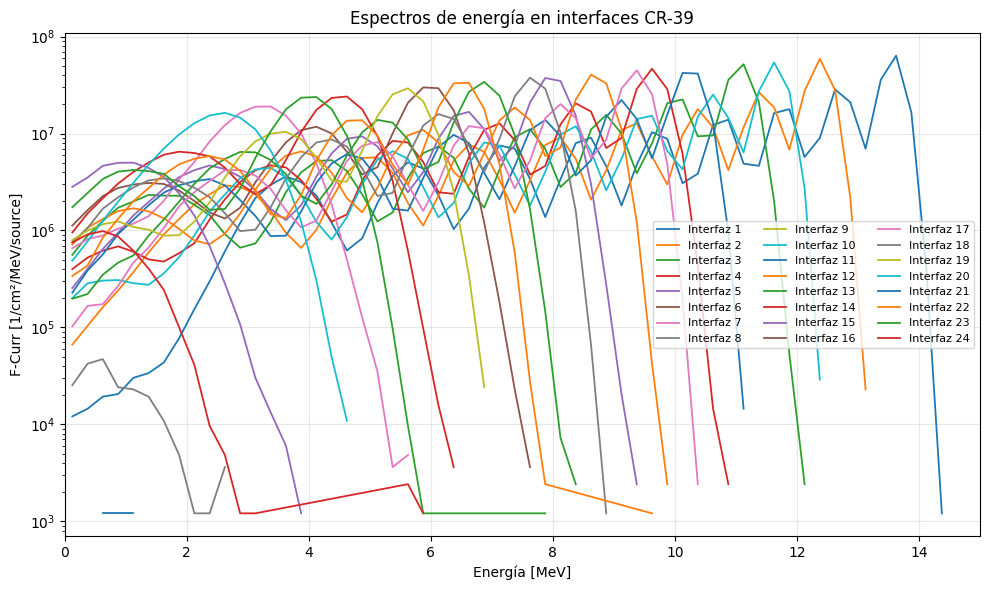

In [3]:
plt.figure(figsize=(10, 6))

for n, (energia, flujo) in espectros.items():
    mask = flujo > 0
    plt.plot(
        energia[mask],
        flujo[mask],
        linewidth=1.3,
        label=f"Interfaz {n}"
    )

plt.xlabel("Energía [MeV]")
plt.ylabel("F-Curr [1/cm²/MeV/source]")
plt.title("Espectros de energía en interfaces CR-39")

plt.yscale("log")
plt.xlim(0, 15)

plt.grid(alpha=0.3)
plt.legend(ncol=3, fontsize=8)

plt.tight_layout()
plt.show()

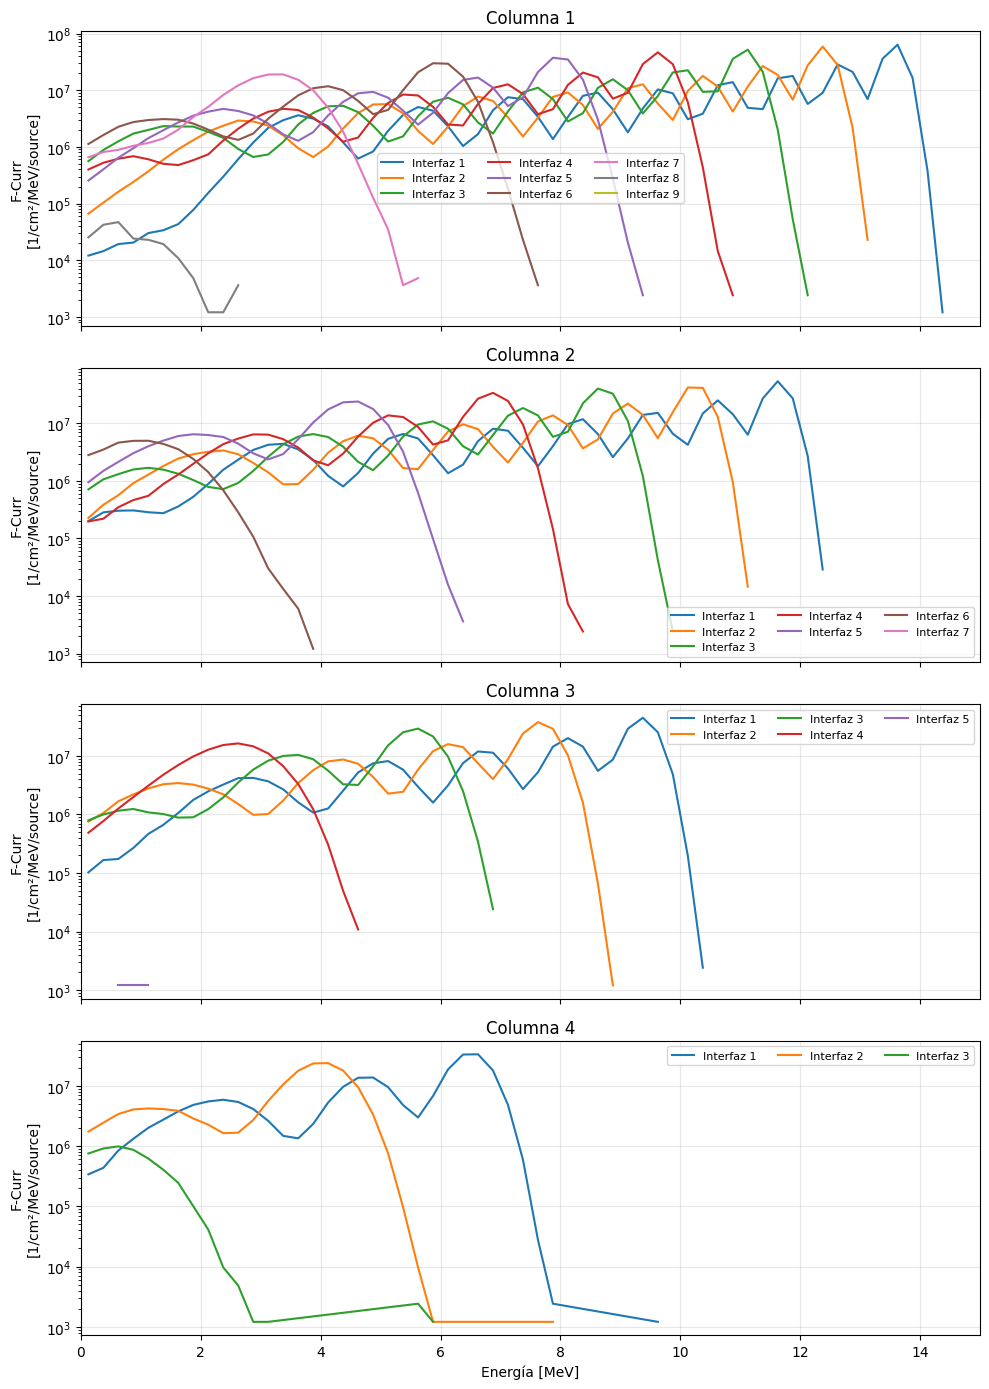

In [4]:
grupos = {
    "Columna 1": range(1, 10),
    "Columna 2": range(10, 17),
    "Columna 3": range(17, 22),
    "Columna 4": range(22, 25),
}

fig, axes = plt.subplots(4, 1, figsize=(10, 14), sharex=True)

for ax, (nombre, indices) in zip(axes, grupos.items()):

    for i, n in enumerate(indices, start=1):
        energia, flujo = espectros[n]

        mask = flujo > 0

        ax.plot(
            energia[mask],
            flujo[mask],
            linewidth=1.5,
            label=f"Interfaz {i}"
        )

    ax.set_yscale("log")
    ax.set_xlim(0, 15)
    ax.set_ylabel("F-Curr\n[1/cm²/MeV/source]")
    ax.set_title(nombre)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, ncol=3)

axes[-1].set_xlabel("Energía [MeV]")

plt.tight_layout()
plt.show()